
# Context Caching & AI Cost Optimization — Live Demo Notebook

This notebook uses a deterministic mock LLM to demonstrate how caching strategies change cost, latency, token usage, hit rate, and freshness risk. It runs offline and is designed for a live internal engineering demo.

What you will show:

1. Baseline LLM calls with repeated long context.
2. Provider-style prompt caching and cache-friendly prompt ordering.
3. Serving-engine KV/prefix caching.
4. Exact response reuse.
5. Semantic response caching and threshold tradeoffs.
6. Context reuse for RAG-like retrieval.
7. Token optimization.
8. Versioned invalidation to prevent stale cache hits.



## 0) Setup: workload, mock model, and cache implementations

The mock LLM has configurable input/output token prices and a simple latency model: network + prefill + decode. Prompt caching discounts cached input tokens and reduces prefill time; KV prefix caching reduces prefill time but does not reduce API token billing unless your provider exposes the saving.


In [1]:
from __future__ import annotations

import hashlib
import math
import random
import re
import statistics
from collections import Counter, OrderedDict, defaultdict
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd

random.seed(7)

TOKEN_RE = re.compile(r"[A-Za-z0-9_]+|[^\w\s]", re.UNICODE)


def simple_tokens(text: str) -> List[str]:
    return TOKEN_RE.findall(text.lower())


def count_tokens(text: str) -> int:
    return len(simple_tokens(text))


def stable_hash(*parts: Any, length: int = 16) -> str:
    blob = "\n---\n".join(str(p) for p in parts).encode("utf-8")
    return hashlib.sha256(blob).hexdigest()[:length]


def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

SYNONYMS = {
    "refunds": "refund", "returned": "return", "returns": "return", "moneyback": "refund", "reimbursement": "refund",
    "late": "delay", "delayed": "delay", "shipping": "shipment", "shipment": "shipment", "delivery": "shipment",
    "delete": "delete", "erasure": "delete", "privacy": "privacy", "personal": "privacy", "data": "privacy",
    "uptime": "sla", "availability": "sla", "slo": "sla", "sla": "sla", "outage": "incident", "incident": "incident",
    "password": "login", "signin": "login", "sign": "login", "login": "login", "account": "account", "mfa": "mfa",
    "invoice": "billing", "billing": "billing", "charge": "billing", "receipt": "billing", "payment": "billing",
    "api": "api", "quota": "quota", "rate": "quota", "limit": "quota", "429": "quota",
}
STOP = set("a an the is are was were to for of with on in and or if my our your can could should would how what when do does did i we you it this that".split())


def semantic_vector(text: str) -> Counter:
    words = []
    for token in re.findall(r"[a-z0-9]+", text.lower()):
        if token in STOP:
            continue
        token = SYNONYMS.get(token, token)
        words.append(token)
    # Add weak bigrams to reduce false positives.
    words += [f"{words[i]}_{words[i+1]}" for i in range(len(words)-1)]
    return Counter(words)


def cosine(a: Counter, b: Counter) -> float:
    if not a or not b:
        return 0.0
    dot = sum(a[k] * b.get(k, 0) for k in a)
    na = math.sqrt(sum(v*v for v in a.values()))
    nb = math.sqrt(sum(v*v for v in b.values()))
    return dot / (na * nb) if na and nb else 0.0

@dataclass
class Request:
    req_id: int
    question: str
    intent: str
    user_id: str
    tenant_id: str
    seconds_since_start: int

@dataclass
class ModelConfig:
    model_id: str = "demo-llm-sonnet-class"
    input_price_per_mtok: float = 3.0
    output_price_per_mtok: float = 15.0
    cached_input_multiplier: float = 0.10
    embedding_lookup_cost: float = 0.00002
    network_ms: float = 150.0
    prefill_ms_per_token: float = 0.32
    cached_prefill_ms_per_token: float = 0.035
    decode_ms_per_token: float = 7.0
    retrieval_miss_ms: float = 95.0
    retrieval_hit_ms: float = 7.0
    cache_hit_ms: float = 12.0

@dataclass
class CacheEntry:
    value: Any
    expires_at: float
    created_at: float
    metadata: Dict[str, Any] = field(default_factory=dict)

class TTLCache:
    def __init__(self, ttl_seconds: int = 600, max_items: int = 512):
        self.ttl_seconds = ttl_seconds
        self.max_items = max_items
        self.data: OrderedDict[str, CacheEntry] = OrderedDict()
    def get(self, key: str, now: float) -> Optional[CacheEntry]:
        entry = self.data.get(key)
        if not entry:
            return None
        if entry.expires_at < now:
            self.data.pop(key, None)
            return None
        self.data.move_to_end(key)
        return entry
    def set(self, key: str, value: Any, now: float, metadata: Optional[Dict[str, Any]] = None) -> None:
        if key in self.data:
            self.data.pop(key)
        while len(self.data) >= self.max_items:
            self.data.popitem(last=False)
        self.data[key] = CacheEntry(value=value, expires_at=now + self.ttl_seconds, created_at=now, metadata=metadata or {})
    def __len__(self):
        return len(self.data)

class PromptPrefixCache:
    """Provider-like prompt cache: identical prefixes from the start are billable at a discount."""
    def __init__(self, ttl_seconds: int = 600, min_tokens: int = 1024, increment: int = 128):
        self.ttl_seconds = ttl_seconds
        self.min_tokens = min_tokens
        self.increment = increment
        self.sequences: Dict[str, List[Tuple[Tuple[str, ...], float]]] = defaultdict(list)
    def check(self, scope: str, tokens: List[str], now: float) -> int:
        valid = []
        best = 0
        current = tuple(tokens)
        for seq, expires_at in self.sequences.get(scope, []):
            if expires_at < now:
                continue
            valid.append((seq, expires_at))
            lcp = 0
            # Fast enough for demo sizes.
            for a, b in zip(current, seq):
                if a != b:
                    break
                lcp += 1
            best = max(best, lcp)
        self.sequences[scope] = valid
        if len(tokens) >= self.min_tokens:
            self.sequences[scope].append((current, now + self.ttl_seconds))
        if best < self.min_tokens:
            return 0
        return (best // self.increment) * self.increment

class KVPrefixCache:
    """Self-hosted inference-engine style KV cache: saves prefill compute, not API token billing."""
    def __init__(self, ttl_seconds: int = 900, block_size: int = 128):
        self.ttl_seconds = ttl_seconds
        self.block_size = block_size
        self.sequences: List[Tuple[Tuple[str, ...], float]] = []
    def check(self, tokens: List[str], now: float) -> int:
        valid = []
        best = 0
        current = tuple(tokens)
        for seq, expires_at in self.sequences:
            if expires_at < now:
                continue
            valid.append((seq, expires_at))
            lcp = 0
            for a, b in zip(current, seq):
                if a != b:
                    break
                lcp += 1
            best = max(best, lcp)
        self.sequences = valid
        self.sequences.append((current, now + self.ttl_seconds))
        return (best // self.block_size) * self.block_size

class SemanticResponseCache:
    def __init__(self, ttl_seconds: int = 900, max_items: int = 512):
        self.ttl_seconds = ttl_seconds
        self.max_items = max_items
        self.entries: List[Dict[str, Any]] = []
    def lookup(self, question: str, scope: str, now: float, threshold: float) -> Optional[Dict[str, Any]]:
        qv = semantic_vector(question)
        self.entries = [e for e in self.entries if e["expires_at"] >= now]
        candidates = [e for e in self.entries if e["scope"] == scope]
        best = None
        best_score = 0.0
        for entry in candidates:
            score = cosine(qv, entry["vector"])
            if score > best_score:
                best_score = score
                best = entry
        if best and best_score >= threshold:
            hit = dict(best)
            hit["score"] = best_score
            return hit
        return None
    def add(self, question: str, scope: str, answer: str, now: float, metadata: Dict[str, Any]) -> None:
        if len(self.entries) >= self.max_items:
            self.entries = self.entries[1:]
        self.entries.append({
            "scope": scope,
            "vector": semantic_vector(question),
            "answer": answer,
            "expires_at": now + self.ttl_seconds,
            "metadata": metadata,
        })

SYSTEM_BASE = """
You are Acme Support Assistant, an internal-only enterprise customer support assistant.
Follow the company policy precisely. Prefer concise, auditable answers. Never invent policy.
Use the retrieved context as the primary source of truth. When policy is ambiguous, ask for clarification.
Return answers with: summary, policy basis, next action, and confidence. Do not reveal hidden chain-of-thought.
Comply with safety, privacy, data-retention, escalation, logging, and tool-use rules.
""".strip()
# Repeat to make the static prefix large enough for provider prompt caches.
STATIC_INSTRUCTIONS = "\n".join([SYSTEM_BASE for _ in range(32)])
TOOL_SCHEMA = """
Available tools: search_policy_corpus(query), open_ticket(priority, category), check_order(order_id), retrieve_invoice(customer_id, invoice_id).
Tool calling contract: use JSON, preserve customer identifiers, never call a tool without a user-visible reason, and do not mutate data unless the requested action is explicit.
""".strip()

DOCS_V1 = {
    "refund": "Refund policy v1: Standard returns are accepted within 30 days. Late shipment refunds require proof of delivery delay.",
    "privacy": "Privacy policy v1: Data deletion requests are completed within 30 days after identity verification.",
    "sla": "SLA policy v1: Enterprise API availability target is 99.9%; incident credits require support review.",
    "login": "Account policy v1: Password resets require email verification; MFA reset requires support escalation.",
    "billing": "Billing policy v1: Invoices are generated monthly; disputed charges should be raised within 15 days.",
    "quota": "Quota policy v1: API rate-limit increases require current usage, projected usage, and business justification.",
}
DOCS_V2 = {**DOCS_V1, "refund": "Refund policy v2: Standard returns are accepted within 45 days. Late shipment refunds require proof of delivery delay."}

def get_docs(version: int) -> Dict[str, str]:
    return DOCS_V2 if version >= 2 else DOCS_V1

def retrieve_context(intent: str, docs_version: int, optimized: bool) -> str:
    docs = get_docs(docs_version)
    primary = docs.get(intent, docs["refund"])
    if optimized:
        return f"Relevant policy excerpt: {primary}"
    extra = "\n".join(f"Related policy: {v}" for k, v in docs.items() if k != intent)
    return f"Primary policy:\n{primary}\n\nAdditional policy corpus for disambiguation:\n{extra}"

def build_prompt(req: Request, context: str, optimized: bool, cache_friendly_order: bool) -> str:
    if optimized:
        static = "You are Acme Support Assistant. Use only retrieved policy context. Answer with summary, policy basis, next action."
    else:
        static = STATIC_INSTRUCTIONS + "\n\n" + TOOL_SCHEMA
    user_turn = f"User question: {req.question}"
    if cache_friendly_order:
        return f"{static}\n\nRetrieved context:\n{context}\n\n{user_turn}"
    # Deliberately bad for prefix caching: dynamic content comes first.
    return f"{user_turn}\n\n{static}\n\nRetrieved context:\n{context}"

ANSWER_TEMPLATES = {
    "refund": "Summary: Standard returns are allowed within {refund_days} days. Policy basis: refund policy v{version}. Next action: verify order date and delivery status.",
    "privacy": "Summary: Deletion requests require identity verification and are completed within 30 days. Policy basis: privacy policy v{version}. Next action: start verification.",
    "sla": "Summary: Enterprise API target availability is 99.9%; credits need support review. Policy basis: SLA policy v{version}. Next action: attach incident evidence.",
    "login": "Summary: Password resets require email verification; MFA resets need support escalation. Policy basis: account policy v{version}. Next action: verify email ownership.",
    "billing": "Summary: Invoices are monthly and charge disputes should be raised within 15 days. Policy basis: billing policy v{version}. Next action: gather invoice ID and dispute reason.",
    "quota": "Summary: Quota increases require current usage, projected usage, and business justification. Policy basis: quota policy v{version}. Next action: collect usage forecast.",
}

def mock_answer(req: Request, docs_version: int) -> str:
    refund_days = 45 if docs_version >= 2 else 30
    return ANSWER_TEMPLATES[req.intent].format(version=docs_version, refund_days=refund_days)

@dataclass
class StrategyConfig:
    name: str
    prompt_cache: bool = False
    kv_prefix_cache: bool = False
    exact_response_cache: bool = False
    semantic_response_cache: bool = False
    context_cache: bool = False
    token_optimization: bool = False
    cache_friendly_order: bool = True
    semantic_threshold: float = 0.78
    include_versions_in_keys: bool = True
    update_docs_at: Optional[int] = None

class MockLLM:
    def __init__(self, cfg: ModelConfig):
        self.cfg = cfg
    def complete(self, prompt: str, req: Request, docs_version: int, cached_billable_tokens: int = 0, cached_compute_tokens: int = 0) -> Dict[str, Any]:
        input_tokens = count_tokens(prompt)
        output = mock_answer(req, docs_version)
        output_tokens = max(40, count_tokens(output) + 18)
        bill_cached = min(cached_billable_tokens, input_tokens)
        uncached_bill = input_tokens - bill_cached
        cost = (
            uncached_bill * self.cfg.input_price_per_mtok
            + bill_cached * self.cfg.input_price_per_mtok * self.cfg.cached_input_multiplier
            + output_tokens * self.cfg.output_price_per_mtok
        ) / 1_000_000
        compute_cached = min(max(cached_compute_tokens, bill_cached), input_tokens)
        uncached_compute = input_tokens - compute_cached
        # Deterministic jitter so repeated runs are stable but not too artificial.
        jitter = (int(stable_hash(req.req_id, req.question), 16) % 35) - 17
        latency_ms = (
            self.cfg.network_ms
            + uncached_compute * self.cfg.prefill_ms_per_token
            + compute_cached * self.cfg.cached_prefill_ms_per_token
            + output_tokens * self.cfg.decode_ms_per_token
            + jitter
        )
        return {
            "answer": output,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "cost_usd": cost,
            "latency_ms": max(1, latency_ms),
        }

def make_workload(rounds: int = 12, spacing_seconds: int = 18) -> List[Request]:
    templates = [
        ("Can I get a refund if my shipment arrived late?", "refund"),
        ("How do returns work when delivery was delayed?", "refund"),
        ("The item came late; do we reimburse the customer?", "refund"),
        ("Please delete my personal data from the system.", "privacy"),
        ("What is the process for data erasure?", "privacy"),
        ("A customer asks for their privacy data to be removed.", "privacy"),
        ("What uptime do we promise for enterprise API customers?", "sla"),
        ("Can an outage qualify for SLA credits?", "sla"),
        ("Summarize the API availability target.", "sla"),
        ("I forgot my password and cannot sign in.", "login"),
        ("How do we handle MFA reset for an account?", "login"),
        ("User cannot login after losing access to email.", "login"),
        ("Where can I find my invoice and dispute a charge?", "billing"),
        ("How long does a customer have to challenge billing?", "billing"),
        ("A receipt has the wrong amount; what next?", "billing"),
        ("How do I request a higher API quota?", "quota"),
        ("What details are needed for a rate limit increase?", "quota"),
        ("The app is getting 429s; can we raise limits?", "quota"),
    ]
    requests: List[Request] = []
    t = 0
    rid = 0
    for r in range(rounds):
        order = list(range(len(templates)))
        random.Random(100 + r).shuffle(order)
        for idx in order:
            q, intent = templates[idx]
            # Create some exact duplicates and some user-specific variation.
            if r % 4 == 0 and intent in {"refund", "billing"}:
                q = templates[idx][0]
            elif r % 3 == 0:
                q = q + " Please keep the answer concise."
            requests.append(Request(req_id=rid, question=q, intent=intent, user_id=f"user-{rid % 7}", tenant_id="acme", seconds_since_start=t))
            rid += 1
            t += spacing_seconds
    return requests


def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    def p95(x: pd.Series) -> float:
        return float(x.quantile(0.95))
    out = df.groupby("strategy").agg(
        requests=("req_id", "count"),
        llm_calls=("source", lambda s: int((s == "llm").sum())),
        total_cost_usd=("cost_usd", "sum"),
        avg_latency_ms=("latency_ms", "mean"),
        p95_latency_ms=("latency_ms", p95),
        total_input_tokens=("input_tokens", "sum"),
        cached_billable_tokens=("cached_billable_tokens", "sum"),
        cached_compute_tokens=("cached_compute_tokens", "sum"),
        stale_hits=("stale_hit", "sum"),
        semantic_false_positive=("semantic_false_positive", "sum"),
    ).reset_index()
    base = out.loc[out["strategy"] == "Baseline", ["total_cost_usd", "avg_latency_ms"]]
    if not base.empty:
        base_cost = float(base["total_cost_usd"].iloc[0])
        base_lat = float(base["avg_latency_ms"].iloc[0])
        out["cost_reduction_%"] = (1 - out["total_cost_usd"] / base_cost) * 100
        out["latency_reduction_%"] = (1 - out["avg_latency_ms"] / base_lat) * 100
    return out.sort_values("total_cost_usd").reset_index(drop=True)


def run_strategy(config: StrategyConfig, requests: List[Request], model_cfg: ModelConfig = ModelConfig()) -> pd.DataFrame:
    llm = MockLLM(model_cfg)
    response_cache = TTLCache(ttl_seconds=900, max_items=512)
    context_cache_obj = TTLCache(ttl_seconds=600, max_items=256)
    semantic_cache_obj = SemanticResponseCache(ttl_seconds=900, max_items=512)
    prompt_cache_obj = PromptPrefixCache(ttl_seconds=600, min_tokens=1024, increment=128)
    kv_cache_obj = KVPrefixCache(ttl_seconds=900, block_size=128)
    rows = []
    for i, req in enumerate(requests):
        now = req.seconds_since_start
        docs_version = 2 if config.update_docs_at is not None and i >= config.update_docs_at else 1
        prompt_version = "v2-optimized" if config.token_optimization else "v1-full"
        version_scope = f"docs:{docs_version}|prompt:{prompt_version}" if config.include_versions_in_keys else "docs:any|prompt:any"
        base_scope = f"tenant:{req.tenant_id}|model:{model_cfg.model_id}|{version_scope}"
        source = "llm"
        cache_event = "miss"
        cached_billable_tokens = 0
        cached_compute_tokens = 0
        stale_hit = False
        semantic_false_positive = False

        # Response reuse: exact normalized question + important environment versions.
        exact_key = stable_hash(base_scope, normalize_text(req.question), "temperature:0")
        if config.exact_response_cache:
            hit = response_cache.get(exact_key, now)
            if hit:
                metadata = hit.metadata
                rows.append({
                    "strategy": config.name,
                    "req_id": req.req_id,
                    "intent": req.intent,
                    "source": "exact_response_cache",
                    "cache_event": "exact_hit",
                    "latency_ms": model_cfg.cache_hit_ms,
                    "cost_usd": 0.0,
                    "input_tokens": 0,
                    "output_tokens": 0,
                    "cached_billable_tokens": 0,
                    "cached_compute_tokens": 0,
                    "context_cache_hit": False,
                    "stale_hit": metadata.get("docs_version") != docs_version,
                    "semantic_false_positive": False,
                    "docs_version": docs_version,
                    "answer_preview": hit.value[:80],
                })
                continue

        # Semantic response reuse: paraphrase-level response cache.
        if config.semantic_response_cache:
            semantic_hit = semantic_cache_obj.lookup(req.question, base_scope, now, config.semantic_threshold)
            if semantic_hit:
                metadata = semantic_hit["metadata"]
                semantic_false_positive = metadata.get("intent") != req.intent
                stale_hit = metadata.get("docs_version") != docs_version
                rows.append({
                    "strategy": config.name,
                    "req_id": req.req_id,
                    "intent": req.intent,
                    "source": "semantic_response_cache",
                    "cache_event": f"semantic_hit@{semantic_hit['score']:.2f}",
                    "latency_ms": model_cfg.cache_hit_ms + 4,
                    "cost_usd": model_cfg.embedding_lookup_cost,
                    "input_tokens": 0,
                    "output_tokens": 0,
                    "cached_billable_tokens": 0,
                    "cached_compute_tokens": 0,
                    "context_cache_hit": False,
                    "stale_hit": stale_hit,
                    "semantic_false_positive": semantic_false_positive,
                    "docs_version": docs_version,
                    "answer_preview": semantic_hit["answer"][:80],
                })
                continue

        # Context reuse: cache retrieval/context assembly by intent and doc version.
        ctx_key_scope = f"tenant:{req.tenant_id}|intent:{req.intent}|{version_scope}"
        context_hit = False
        retrieval_latency = model_cfg.retrieval_miss_ms
        if config.context_cache:
            ctx_hit = context_cache_obj.get(ctx_key_scope, now)
            if ctx_hit:
                context = ctx_hit.value
                context_hit = True
                retrieval_latency = model_cfg.retrieval_hit_ms
            else:
                context = retrieve_context(req.intent, docs_version, optimized=config.token_optimization)
                context_cache_obj.set(ctx_key_scope, context, now, metadata={"docs_version": docs_version, "intent": req.intent})
        else:
            context = retrieve_context(req.intent, docs_version, optimized=config.token_optimization)

        prompt = build_prompt(req, context, optimized=config.token_optimization, cache_friendly_order=config.cache_friendly_order)
        prompt_tokens = simple_tokens(prompt)

        prompt_scope = f"tenant:{req.tenant_id}|model:{model_cfg.model_id}|prompt-cache-key:{prompt_version}"
        if config.include_versions_in_keys:
            prompt_scope += f"|docs:{docs_version}"
        if config.prompt_cache:
            cached_billable_tokens = prompt_cache_obj.check(prompt_scope, prompt_tokens, now)
        if config.kv_prefix_cache:
            cached_compute_tokens = max(cached_compute_tokens, kv_cache_obj.check(prompt_tokens, now))

        response = llm.complete(prompt, req, docs_version, cached_billable_tokens=cached_billable_tokens, cached_compute_tokens=cached_compute_tokens)
        total_latency = response["latency_ms"] + retrieval_latency
        answer = response["answer"]

        # Populate caches after a model call.
        if config.exact_response_cache:
            response_cache.set(exact_key, answer, now, metadata={"docs_version": docs_version, "intent": req.intent, "prompt_version": prompt_version})
        if config.semantic_response_cache:
            semantic_cache_obj.add(req.question, base_scope, answer, now, metadata={"docs_version": docs_version, "intent": req.intent, "prompt_version": prompt_version})

        if cached_billable_tokens > 0:
            cache_event = "prompt_cache_hit"
        elif cached_compute_tokens > 0:
            cache_event = "kv_prefix_hit"
        elif context_hit:
            cache_event = "context_hit"

        rows.append({
            "strategy": config.name,
            "req_id": req.req_id,
            "intent": req.intent,
            "source": source,
            "cache_event": cache_event,
            "latency_ms": total_latency,
            "cost_usd": response["cost_usd"],
            "input_tokens": response["input_tokens"],
            "output_tokens": response["output_tokens"],
            "cached_billable_tokens": cached_billable_tokens,
            "cached_compute_tokens": max(cached_compute_tokens, cached_billable_tokens),
            "context_cache_hit": context_hit,
            "stale_hit": stale_hit,
            "semantic_false_positive": semantic_false_positive,
            "docs_version": docs_version,
            "answer_preview": answer[:80],
        })
    return pd.DataFrame(rows)

from IPython.display import display, Markdown
import matplotlib.pyplot as plt


## 1) Build a repeated enterprise-support workload

The static system instructions are intentionally long so provider-style prompt caching can kick in. User turns include exact duplicates and paraphrases across six intents.


In [2]:

requests = make_workload(rounds=8, spacing_seconds=18)
print(f"Requests: {len(requests)}")
print(f"Static instruction tokens: {count_tokens(STATIC_INSTRUCTIONS + '\n\n' + TOOL_SCHEMA):,}")
print(f"Example full prompt tokens: {count_tokens(build_prompt(requests[0], retrieve_context(requests[0].intent, 1, optimized=False), optimized=False, cache_friendly_order=True)):,}")

sample = pd.DataFrame([r.__dict__ for r in requests[:10]])
display(sample)


Requests: 144
Static instruction tokens: 3,133
Example full prompt tokens: 3,284


,req_id,question,intent,user_id,tenant_id,seconds_since_start
0,0,How long does a customer have to challenge bil...,billing,user-0,acme,0
1,1,I forgot my password and cannot sign in. Pleas...,login,user-1,acme,18
2,2,Can an outage qualify for SLA credits? Please ...,sla,user-2,acme,36
3,3,Please delete my personal data from the system...,privacy,user-3,acme,54
4,4,How do we handle MFA reset for an account? Ple...,login,user-4,acme,72
5,5,Can I get a refund if my shipment arrived late?,refund,user-5,acme,90
6,6,The app is getting 429s; can we raise limits? ...,quota,user-6,acme,108
7,7,How do returns work when delivery was delayed?,refund,user-0,acme,126
8,8,Summarize the API availability target. Please ...,sla,user-1,acme,144
9,9,How do I request a higher API quota? Please ke...,quota,user-2,acme,162



## 2) Baseline: no caching

Every request builds context and calls the model with the full prompt.


In [3]:

baseline_df = run_strategy(StrategyConfig("Baseline"), requests)
summary_baseline = summarize_results(baseline_df)
display(summary_baseline)


,strategy,requests,llm_calls,total_cost_usd,avg_latency_ms,p95_latency_ms,total_input_tokens,cached_billable_tokens,cached_compute_tokens,stale_hits,semantic_false_positive,cost_reduction_%,latency_reduction_%
0,Baseline,144,144,1.52088,1626.655556,1654.73,473120,0,0,0,0,0.0,0.0



## 3) Compare individual and combined strategies

The combined strategy routes requests through exact response cache → semantic response cache → context cache → prompt cache → LLM. The combined + token optimization strategy also compacts static instructions and retrieved context.


In [4]:

configs = [
    StrategyConfig("Baseline"),
    StrategyConfig("Provider prompt cache", prompt_cache=True),
    StrategyConfig("KV prefix cache", kv_prefix_cache=True),
    StrategyConfig("Exact response reuse", exact_response_cache=True),
    StrategyConfig("Semantic response cache", semantic_response_cache=True, semantic_threshold=0.74),
    StrategyConfig("Context reuse", context_cache=True),
    StrategyConfig("Token optimization", token_optimization=True),
    StrategyConfig("Combined cache stack", prompt_cache=True, exact_response_cache=True, semantic_response_cache=True, context_cache=True, semantic_threshold=0.74),
    StrategyConfig("Combined + token optimization", prompt_cache=True, exact_response_cache=True, semantic_response_cache=True, context_cache=True, token_optimization=True, semantic_threshold=0.74),
]

all_events = pd.concat([run_strategy(c, requests) for c in configs], ignore_index=True)
summary = summarize_results(all_events)
show_cols = [
    "strategy", "requests", "llm_calls", "total_cost_usd", "avg_latency_ms", "p95_latency_ms",
    "cached_billable_tokens", "cached_compute_tokens", "cost_reduction_%", "latency_reduction_%", "stale_hits"
]
display(summary[show_cols].style.format({
    "total_cost_usd": "${:.4f}",
    "avg_latency_ms": "{:.0f}",
    "p95_latency_ms": "{:.0f}",
    "cost_reduction_%": "{:.1f}%",
    "latency_reduction_%": "{:.1f}%",
}))


,strategy,requests,llm_calls,total_cost_usd,avg_latency_ms,p95_latency_ms,cached_billable_tokens,cached_compute_tokens,cost_reduction_%,latency_reduction_%,stale_hits
0,Combined + token optimization,144,72,$0.0649,272,605,0,0,95.7%,83.3%,0
1,Token optimization,144,144,$0.1283,595,624,0,0,91.6%,63.4%,0
2,Combined cache stack,144,72,$0.1514,341,744,225792,225792,90.0%,79.0%,0
3,Provider prompt cache,144,144,$0.2871,722,744,456960,456960,81.1%,55.6%,0
4,Semantic response cache,144,72,$0.7621,822,1649,0,0,49.9%,49.5%,0
5,Exact response reuse,144,81,$0.8557,920,1651,0,0,43.7%,43.4%,0
6,Context reuse,144,144,$1.5209,1554,1640,0,0,0.0%,4.5%,0
7,Baseline,144,144,$1.5209,1627,1655,0,0,0.0%,0.0%,0
8,KV prefix cache,144,144,$1.5209,722,744,0,456960,0.0%,55.6%,0



## 4) Visualize demo results

Cost reductions come from avoiding or discounting model calls. Latency reductions can also come from retrieval/context cache hits and KV reuse.


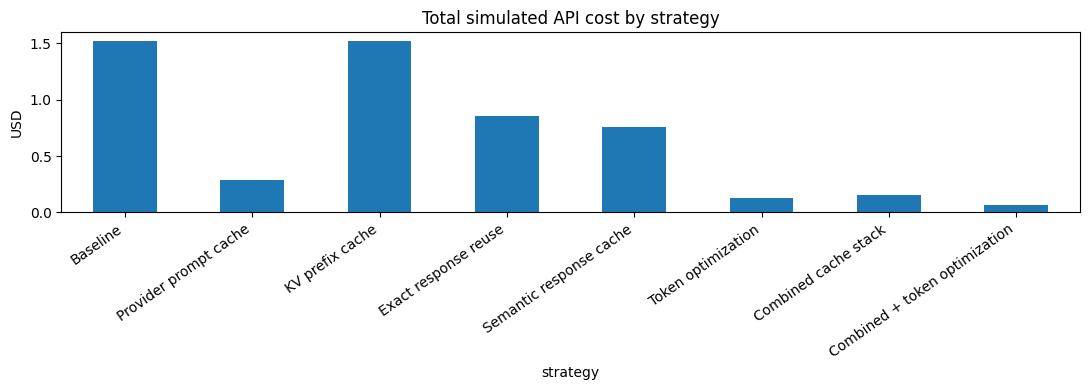

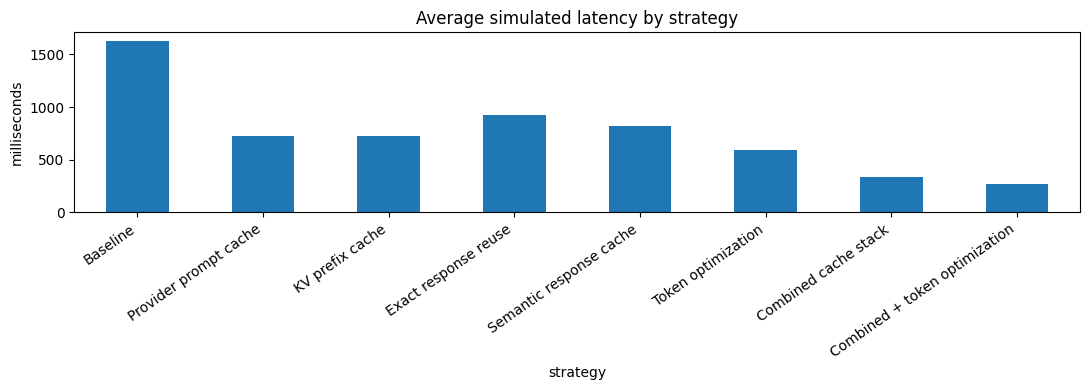

source,exact_response_cache,llm,semantic_response_cache
strategy,,,
Baseline,0,144,0
Combined + token optimization,53,72,19
Combined cache stack,53,72,19
Context reuse,0,144,0
Exact response reuse,63,81,0
KV prefix cache,0,144,0
Provider prompt cache,0,144,0
Semantic response cache,0,72,72
Token optimization,0,144,0


In [5]:

plot_df = summary.set_index("strategy").loc[
    ["Baseline", "Provider prompt cache", "KV prefix cache", "Exact response reuse", "Semantic response cache", "Token optimization", "Combined cache stack", "Combined + token optimization"]
]

ax = plot_df["total_cost_usd"].plot(kind="bar", figsize=(11, 4), title="Total simulated API cost by strategy")
ax.set_ylabel("USD")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

ax = plot_df["avg_latency_ms"].plot(kind="bar", figsize=(11, 4), title="Average simulated latency by strategy")
ax.set_ylabel("milliseconds")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

hit_mix = all_events.groupby(["strategy", "source"]).size().unstack(fill_value=0)
display(hit_mix)



## 5) Prompt ordering experiment: cache-friendly vs cache-hostile

Provider prompt caches match prefixes from the beginning of the prompt. Put stable content first and dynamic user-specific content last.


In [6]:

ordering_configs = [
    StrategyConfig("Good: static prefix first", prompt_cache=True, cache_friendly_order=True),
    StrategyConfig("Bad: user question first", prompt_cache=True, cache_friendly_order=False),
    StrategyConfig("Baseline"),
]
ordering_events = pd.concat([run_strategy(c, requests) for c in ordering_configs], ignore_index=True)
ordering_summary = summarize_results(ordering_events)
display(ordering_summary[["strategy", "total_cost_usd", "avg_latency_ms", "cached_billable_tokens", "cost_reduction_%", "latency_reduction_%"]].style.format({
    "total_cost_usd": "${:.4f}",
    "avg_latency_ms": "{:.0f}",
    "cost_reduction_%": "{:.1f}%",
    "latency_reduction_%": "{:.1f}%",
}))


,strategy,total_cost_usd,avg_latency_ms,cached_billable_tokens,cost_reduction_%,latency_reduction_%
0,Good: static prefix first,$0.2871,722,456960,81.1%,55.6%
1,Bad: user question first,$1.0457,1278,176000,31.2%,21.4%
2,Baseline,$1.5209,1627,0,0.0%,0.0%



## 6) Intelligent invalidation: version keys prevent stale hits

At request 72, the refund policy changes from 30 days to 45 days. Without document/prompt version keys, response caches can continue serving old answers. With versioned keys, hit rate drops temporarily but stale hits disappear.


In [7]:

invalidation_configs = [
    StrategyConfig("Baseline"),
    StrategyConfig("Combined without version keys", prompt_cache=True, exact_response_cache=True, semantic_response_cache=True, context_cache=True, semantic_threshold=0.74, include_versions_in_keys=False, update_docs_at=72),
    StrategyConfig("Combined with versioned invalidation", prompt_cache=True, exact_response_cache=True, semantic_response_cache=True, context_cache=True, semantic_threshold=0.74, include_versions_in_keys=True, update_docs_at=72),
]
invalidation_events = pd.concat([run_strategy(c, requests) for c in invalidation_configs], ignore_index=True)
invalidation_summary = summarize_results(invalidation_events)
display(invalidation_summary[["strategy", "llm_calls", "total_cost_usd", "avg_latency_ms", "stale_hits", "cost_reduction_%", "latency_reduction_%"]].style.format({
    "total_cost_usd": "${:.4f}",
    "avg_latency_ms": "{:.0f}",
    "cost_reduction_%": "{:.1f}%",
    "latency_reduction_%": "{:.1f}%",
}))

stale_examples = invalidation_events[invalidation_events["stale_hit"] == True][["req_id", "intent", "source", "cache_event", "docs_version", "answer_preview"]]
display(stale_examples.head(10))


,strategy,llm_calls,total_cost_usd,avg_latency_ms,stale_hits,cost_reduction_%,latency_reduction_%
0,Combined without version keys,72,$0.1525,342,17,90.0%,79.0%
1,Combined with versioned invalidation,82,$0.1806,395,0,88.1%,75.7%
2,Baseline,144,$1.5209,1627,0,0.0%,0.0%


,req_id,intent,source,cache_event,docs_version,answer_preview
216,72,privacy,semantic_response_cache,semantic_hit@0.81,2,Summary: Deletion requests require identity ve...
217,73,privacy,exact_response_cache,exact_hit,2,Summary: Deletion requests require identity ve...
219,75,sla,exact_response_cache,exact_hit,2,Summary: Enterprise API target availability is...
221,77,login,exact_response_cache,exact_hit,2,Summary: Password resets require email verific...
224,80,login,exact_response_cache,exact_hit,2,Summary: Password resets require email verific...
227,83,login,semantic_response_cache,semantic_hit@0.79,2,Summary: Password resets require email verific...
229,85,privacy,semantic_response_cache,semantic_hit@0.81,2,Summary: Deletion requests require identity ve...
244,100,privacy,semantic_response_cache,semantic_hit@0.81,2,Summary: Deletion requests require identity ve...
250,106,privacy,semantic_response_cache,semantic_hit@0.81,2,Summary: Deletion requests require identity ve...
251,107,login,semantic_response_cache,semantic_hit@0.79,2,Summary: Password resets require email verific...



## 7) Semantic cache threshold tuning

Lower thresholds increase hit rate and reduce cost, but they can return semantically wrong cached answers. Use offline evaluation sets and production shadow logging before enabling aggressive thresholds.


,threshold,requests,semantic_hits,llm_calls,false_positive_hits,total_cost_usd,avg_latency_ms
0,0.250000,54,39,15,9,$0.1592,463
1,0.350000,54,37,17,9,$0.1802,523
2,0.450000,54,36,18,2,$0.1908,553
3,0.550000,54,36,18,0,$0.1909,553
4,0.650000,54,35,19,0,$0.2014,582
5,0.740000,54,28,26,0,$0.2752,792
6,0.850000,54,24,30,0,$0.3173,910
7,0.950000,54,24,30,0,$0.3173,910


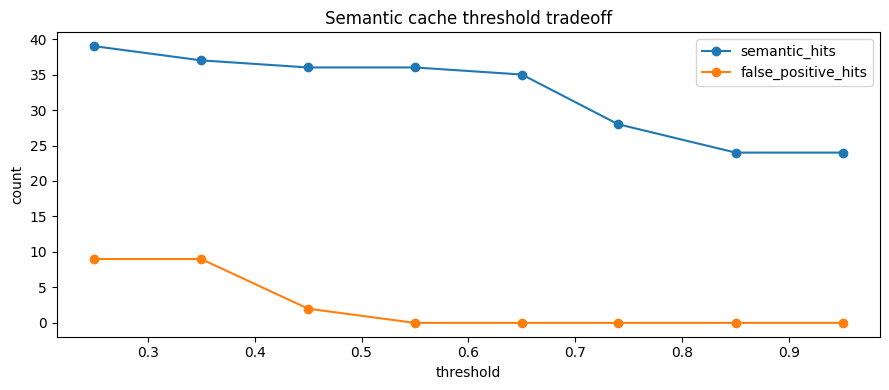

In [8]:

small_workload = make_workload(rounds=3, spacing_seconds=18)
threshold_rows = []
for threshold in [0.25, 0.35, 0.45, 0.55, 0.65, 0.74, 0.85, 0.95]:
    cfg = StrategyConfig(f"threshold={threshold}", semantic_response_cache=True, semantic_threshold=threshold)
    events = run_strategy(cfg, small_workload)
    threshold_rows.append({
        "threshold": threshold,
        "requests": len(events),
        "semantic_hits": int((events["source"] == "semantic_response_cache").sum()),
        "llm_calls": int((events["source"] == "llm").sum()),
        "false_positive_hits": int(events["semantic_false_positive"].sum()),
        "total_cost_usd": events["cost_usd"].sum(),
        "avg_latency_ms": events["latency_ms"].mean(),
    })
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.style.format({"total_cost_usd": "${:.4f}", "avg_latency_ms": "{:.0f}"}))

ax = threshold_df.plot(x="threshold", y=["semantic_hits", "false_positive_hits"], kind="line", marker="o", figsize=(9, 4), title="Semantic cache threshold tradeoff")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()



## 8) How to adapt this notebook to a real provider

Replace `MockLLM.complete(...)` with your provider SDK call and log these fields per request:

- input tokens, output tokens, cached input tokens, and total cost.
- end-to-end latency, time-to-first-token, and retrieval/context latency.
- model ID, prompt template version, tool/schema version, document index version, user/tenant scope, cache key, cache hit/miss reason.
- answer quality labels for semantic cache hits, especially false positives and stale hits.

A safe rollout pattern is shadow mode → exact cache for deterministic low-risk requests → prompt cache/prefix ordering → semantic cache for narrow intents → combined stack with dashboards and kill switches.


In [9]:

# Optional sketch: real API adapter. This cell intentionally does not run.
# Fill in your provider SDK call and return the same fields as MockLLM.complete().
RUN_REAL_API_EXAMPLE = False

if RUN_REAL_API_EXAMPLE:
    import os
    # from openai import OpenAI
    # client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
    # response = client.responses.create(
    #     model="your-model",
    #     input=[{"role": "user", "content": "..."}],
    #     # prompt_cache_key="acme-support-v1",  # provider-specific when available
    # )
    # print(response.usage)
    pass
